<a href="https://colab.research.google.com/github/huile09/AI.Homework/blob/main/AI_B%C3%A0i_t%E1%BA%ADp_tu%E1%BA%A7n_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cài đặt
!pip install folium geopy osmnx networkx
!pip install osmnx networkx
!pip install geopandas

**23.1.** Sử dụng thư viện Folium, bạn hãy xây dựng một bản đồ tương tác hiển thị vị trí của UEH hoặc trường Đại học đang theo học hoặc một địa điểm trung tâm được lựa chọn. Trên bản đồ cần thể hiện tối thiểu năm địa điểm công cộng lân cận như bệnh viện, trung tâm thương mại, bến xe hoặc cơ quan hành chính. Mỗi địa điểm phải được gắn marker có popup mô tả ngắn gọn thông tin. Bản đồ cần có khả năng phóng to, thu nhỏ và bật/tắt các lớp dữ liệu.

In [ ]:
from google import colab
import folium
uehb = (10.761295603162457, 106.66833654397013) # Trung tâm
# Địa điểm lân cận
locations = {
    'Bệnh viện Chợ Rẫy':(10.7580648, 106.6595238),
    'Vạn Hạnh Mall':(10.7707539, 106.6698906),
    'Công viên Lý Thái Tổ':(10.7654509, 106.6797695),
    'NowZone':(10.7642682, 106.6825759),
    'Hồ Con Rùa':(10.7825913, 106.6957684)
}
# Tạo một lớp dữ liệu (FeatureGroup)
fg = folium.FeatureGroup(name="Các địa điểm lân cận")
# Tạo map
m1 = folium.Map(location = uehb, zoom_start = 14,  tiles='cartodbpositron')
# Gắn marker
folium.Marker(uehb, popup='Đại học Kinh tế TP.HCM - Cơ sở B',
              icon=folium.Icon(color='red', icon='star')).add_to(m1)
for name in locations.keys():
    folium.Marker(location=locations[name], popup=name, tooltip='Hiển thị',icon=folium.Icon(color='blue')).add_to(fg)
fg.add_to(m1)
# Lớp bật tắt dữ liệu
folium.LayerControl().add_to(m1)
m1

**23.2.** Sử dụng GeoPy, bạn hãy thu thập hoặc giả lập danh sách tối thiểu mười địa chỉ cụ thể. Thực hiện chuyển đổi các địa chỉ này sang tọa độ địa lý (vĩ độ, kinh độ) và tính khoảng cách từ mỗi địa chỉ đến một điểm trung tâm xác định trước. Kết quả cần được trực quan hóa trên bản đồ Folium, trong đó thể hiện rõ vị trí, khoảng cách và mối quan hệ không gian giữa các điểm.


In [ ]:
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import pandas as pd
import time
import folium
# Tọa độ trung tâm
cvltt = (10.765450980070375, 106.67976958634287) # Công viên Lý Thái Tổ
# Tạo map
m2 = folium.Map(location = cvltt, zoom_start = 14,  tiles='cartodbpositron')
# Địa điểm
diadiem = {'Bến Nhà Rồng': 'Bến Nhà Rồng, Ho Chi Minh City',
           'Chợ Bến Thành': 'Ben Thanh Market, Ho Chi Minh City',
           'Dinh Độc Lập': 'Independence Palace, Ho Chi Minh City',
           'Landmark 81': 'Landmark 81, Ho Chi Minh City',
           'Sân bay Tân Sơn Nhất': 'Tan Son Nhat Airport, Ho Chi Minh City',
           'Bitexco Tower': 'Bitexco Financial Tower, Ho Chi Minh City',
           'Thảo Cầm Viên': 'Saigon Zoo, Ho Chi Minh City',
           'Bảo tàng Chứng tích Chiến tranh': 'War Remnants Museum, Ho Chi Minh City',
           'Vạn Hạnh Mall': 'Van Hanh Mall, Ho Chi Minh City',
           'Công viên Tao Đàn': 'Tao Dan Park, Ho Chi Minh City'
}
# Tọa độ 10 địa điểm
geolocator = Nominatim(user_agent = 'geoapi')
for place in diadiem.keys():
  try:
    location = geolocator.geocode(diadiem[place]) # Lấy thông tin địa điểm
    lat = location.latitude # Lấy vĩ độ
    lon = location.longitude # Lấy kinh độ
    loc = (location.latitude, location.longitude) # Tạo tuple tọa độ
    distance = geodesic((lat, lon),cvltt).km
    print(f'Khoảng cách giữa {place} và Công viên Lý Thái Tổ là: {round(distance, 2)} km')
    folium.Marker(loc, popup = f'{place} - cách {round(distance,2)} km', tooltip = 'Hiển thị', icon = folium.Icon(color = 'blue', icon ='info-sign')).add_to(m2)
    folium.PolyLine([cvltt, loc], color = 'black').add_to(m2)
  except:
    print(f'Không tìm thấy địa điểm: {place}')
  time.sleep(1)
folium.Marker(cvltt, popup = 'Công viên Lý Thái Tổ', tooltip = 'Hiển thị', icon = folium.Icon(color = 'red', icon = 'star')).add_to(m2)
m2

Khoảng cách giữa Bến Nhà Rồng và Công viên Lý Thái Tổ là: 2.96 km
Khoảng cách giữa Chợ Bến Thành và Công viên Lý Thái Tổ là: 2.15 km
Khoảng cách giữa Dinh Độc Lập và Công viên Lý Thái Tổ là: 2.14 km
Khoảng cách giữa Landmark 81 và Công viên Lý Thái Tổ là: 8.48 km
Khoảng cách giữa Sân bay Tân Sơn Nhất và Công viên Lý Thái Tổ là: 6.35 km
Khoảng cách giữa Bitexco Tower và Công viên Lý Thái Tổ là: 2.79 km
Khoảng cách giữa Thảo Cầm Viên và Công viên Lý Thái Tổ là: 3.82 km
Khoảng cách giữa Bảo tàng Chứng tích Chiến tranh và Công viên Lý Thái Tổ là: 2.06 km
Khoảng cách giữa Vạn Hạnh Mall và Công viên Lý Thái Tổ là: 1.25 km
Khoảng cách giữa Công viên Tao Đàn và Công viên Lý Thái Tổ là: 1.8 km


**23.3.** Bạn hãy tạo một bản đồ nhiệt (heatmap) thể hiện mật độ phân bố của một hiện tượng không gian như khách hàng, đơn hàng, dân cư hoặc điểm giao dịch (dữ liệu có thể giả lập). Bản đồ phải cho phép người xem nhận biết trực quan các khu vực có mật độ cao và thấp, đồng thời giải thích ý nghĩa quản trị của các vùng nóng trên bản đồ.


In [ ]:
import pandas as pd
import folium
from folium.plugins import HeatMap

df = pd.read_csv('dan_so_q1.csv')
m3 = folium.Map(location=[10.7769, 106.7009], zoom_start=14,  tiles='cartodbpositron')

data_heatmap = df[['Latitude', 'Longitude', 'Population_Count']].values.tolist()

# Vẽ Heatmap
HeatMap(data_heatmap,
        min_opacity=0.4,
       ).add_to(m3)

m3

Ý nghĩa quản trị: Vùng "nóng" (đỏ đậm) chỉ ra nơi tập trung nhu cầu cực cao. Nhờ đó, nhà quản trị có thể phân bổ lại nhân sự (tăng tài xế, mở rộng kho bãi) ngay tại điểm nóng để đáp ứng kịp thời, tránh quá tải và tối ưu doanh thu.

**23.4.** Sử dụng GeoPandas, hãy đọc dữ liệu ranh giới hành chính (tỉnh, thành phố hoặc phường/xã) và kết hợp với một tập dữ liệu số tương ứng như dân số, doanh thu, số lượng đơn hàng hoặc mức độ tiêu thụ. Kết quả cần được thể hiện dưới dạng bản đồ choropleth, phản ánh sự khác biệt không gian giữa các khu vực và đưa ra nhận xét ngắn về ý nghĩa quản trị.

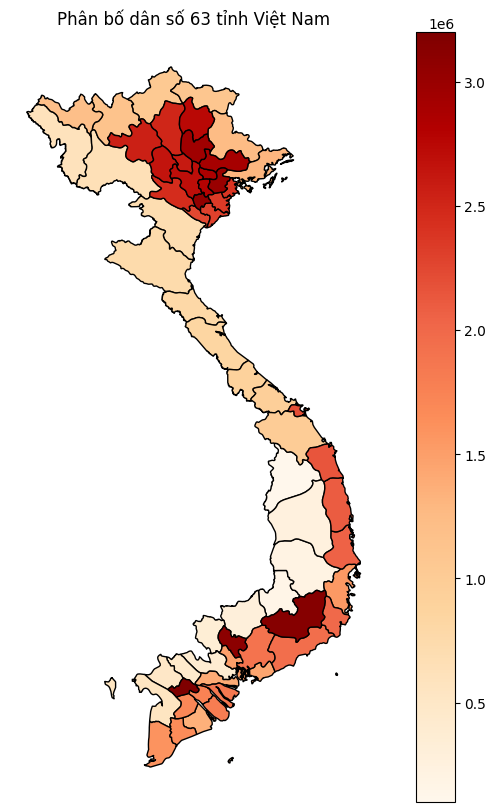

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
# Đọc data
gdf = gpd.read_file('/content/vn.json')

data = {
    'name': gdf['name'],
    'population': range(100000, 100000 + len(gdf)*50000, 50000)
}
df = pd.DataFrame(data)

gdf = gdf.merge(df, on='name', how='left')
gdf.plot(
    column='population',
    cmap='OrRd',
    legend=True,
    edgecolor='black',
    figsize=(10,10)
)
plt.title('Phân bố dân số 63 tỉnh Việt Nam')
plt.axis('off')
plt.show()

Ý nghĩa quản trị: Bản đồ này giúp so sánh trực quan tiềm năng (dân số) giữa các quận/huyện
. Từ đó, quản lý có thể quyết định rót thêm vốn Marketing vào vùng tiềm năng, hoặc thiết lập lại KPI cho vùng có hiệu suất kém

**23.5.** Bạn hãy xây dựng mô hình phân tích vùng phục vụ (service area) cho một trung tâm phân phối, kho hàng hoặc trạm dịch vụ. Sử dụng dữ liệu tọa độ để vẽ các vòng bán kính phục vụ khác nhau (ví dụ: 3 km, 5 km và 10 km) và trực quan hóa trên bản đồ. Bài làm cần đánh giá khả năng tiếp cận khách hàng của từng vùng và đề xuất phạm vi hoạt động tối ưu.

In [ ]:
import folium
from folium import plugins
import pandas as pd
center = (10.7905, 106.7379)
center_name = 'Trung tâm phân phối'
m5 = folium.Map(location=center, zoom_start=12,  tiles='cartodbpositron')
service_zones = [
    {'radius': 3000, 'color': 'green', 'label': 'Vùng phục vụ nhanh (3km)'},
    {'radius': 5000, 'color': 'yellow', 'label': 'Vùng phục vụ tiêu chuẩn (5km)'},
    {'radius': 10000, 'color': 'red', 'label':'Vùng phục vụ mở rộng (10km)'}
]
for vung in service_zones:
    folium.Circle(location=center,radius=vung["radius"], color=vung["color"],fill=True, fill_opacity=0.1,popup=f'{vung['label']}').add_to(m5)
folium.Marker(location=center,popup="Trung tâm",icon=folium.Icon(color='blue', icon='home')).add_to(m5)
customers = {"Khách A": (10.800, 106.720),
           "Khách B": (10.750, 106.730),
           "Khách C": (10.850, 106.750)
}
for kh in customers.keys():
    folium.CircleMarker(location=customers[kh],radius=5,color='black',fill=True, popup=kh).add_to(m5)
display(m5)

Đánh giá & Đề xuất: Vùng lõi (3km) có khả năng tiếp cận nhanh nhất với chi phí rẻ nhất. Đề xuất: Ưu tiên chốt đơn mạnh ở vùng lõi; đối với vùng rìa (10km), cần tính thêm phụ phí vận chuyển hoặc cân nhắc mở thêm kho trung chuyển mini nếu lượng khách đủ lớn để tối ưu thời gian giao

**23.6.** Sử dụng OSMnx, hãy tải dữ liệu mạng lưới giao thông đường bộ của một khu vực đô thị cụ thể. Trực quan hóa mạng đường trên bản đồ và thực hiện một số phân tích cơ bản như số lượng nút giao, chiều dài đường trung bình hoặc mật độ mạng. Trình bày vai trò của dữ liệu mạng giao thông trong các hệ thống AI đô thị thông minh.




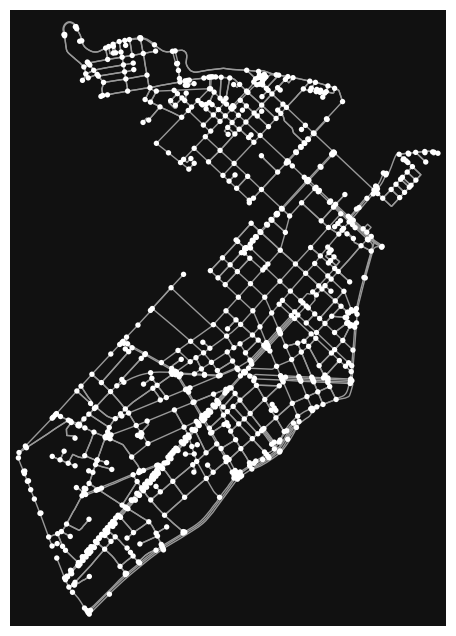

Số nút giao thông: 989
Số đoạn đường: 2088
Độ dài trung bình đường: 0.08 km
Tổng độ dài đường: 118.27 km
Diện tích khu vực: 7.7 km2
Mật độ mạng: 15.36 km/km2


In [ ]:
# Import thư viện
import osmnx as ox
import networkx as nx
import geopandas as gpd
import folium

# Xác định khu vực, vẽ map
place_name = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type = 'drive')
ox.plot_graph(G)
# Thống kê
stats = ox.basic_stats(G)
so_nut = stats['n'] # Số nút
so_duong = stats['m'] # Số đoạn đường
avg_len = stats['street_length_avg'] # Độ dài trung bình đoạn đường
total_len = stats['street_length_total'] # Tổng độ dài mạng lưới

gdf = ox.geocode_to_gdf(place_name)
gdf_projected = ox.projection.project_gdf(gdf)
dientich_km2 = gdf_projected.area.iloc[0] / 10**6 # Diện tích (km2)
matdomang = (total_len/1000)/dientich_km2 # Mật độ mạng
# Phân tích
print(f'Số nút giao thông: {so_nut}')
print(f'Số đoạn đường: {so_duong}')
print(f'Độ dài trung bình đường: {round(avg_len/1000,2)} km')
print(f'Tổng độ dài đường: {round(total_len/1000,2)} km')
print(f'Diện tích khu vực: {round(dientich_km2,2)} km2')
print(f'Mật độ mạng: {round(matdomang,2)} km/km2')

dinh = (10.777162833676407, 106.69523772694613)
# Tạo bản đồ Folium bằng tay
m6 = folium.Map(dinh, zoom_start=14, control_scale=True,  tiles='cartodbpositron')
display(m6)

Vai trò của dữ liệu mạng giao thông trong các hệ thống AI đô thị thông minh nhờ OSMnx và NetworkX:
- **Trong logistics**: giúp tối ưu hóa bằng cách tìm tuyến đường ngắn nhất giữa các điểm trong thành phố thông qua tải mạng lưới đường bộ và tính toán lộ trình tối ưu dựa trên độ dài và thời gian di chuyển
- **Trong quy hoạch đô thị**: hỗ trợ phân tích cấu trúc mạng lưới giao thông quy mô lớn như xác định giao lộ quan trọng nơi dễ ùn tắc hoặc có vai trò quan trọng trong di chuyển; phân tích độ kết nối và tính dễ tổn thương của mạng lưới giúp đánh giá tác động của việc đóng đường, xây cầu và mở tuyến mới.
- **Trong trực quan hóa bản đồ**: vẽ mạng lưới đường phố với nhiều tùy chỉnh hiển thị, làm nổi bật yếu tố quan trọng, giúp dễ truyền đạt cho người không chuyên về kỹ thuật
- **Khác**: phân tích thống kê, xử lý dữ liệu không gian nâng cao, xây dựng bản đồ tương tác trên web, phục vụ nghiên cứu chuyên sâu giao thông và đô thị

**23.7.** Kết hợp OSMnx và NetworkX, bạn hãy xây dựng chương trình tìm đường đi ngắn nhất giữa hai địa điểm bất kỳ trong khu vực nghiên cứu. So sánh kết quả giữa ít nhất hai thuật toán khác nhau (ví dụ: Dijkstra và A*). Tuyến đường tìm được cần được hiển thị trực quan trên bản đồ và phân tích ưu - nhược điểm của từng phương pháp.


In [ ]:
import osmnx as ox
import networkx as nx
import folium
import time
from folium import PolyLine

# Tải bản đồ
place = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type='drive')

# Gán trọng số là chiều dài (mét)
for u, v, k, data in G.edges(keys=True, data=True):
    data['weight'] = data['length']

# Điểm bắt đầu và kết thúc
coord_start = (10.7796, 106.7000)
coord_end   = (10.7720, 106.6940)

start_node = ox.distance.nearest_nodes(G, coord_start[1], coord_start[0])
end_node   = ox.distance.nearest_nodes(G, coord_end[1], coord_end[0])

# Hàm heuristic cho A* (khoảng cách đường chim bay)
def heuristic(u, v):
    uy, ux = G.nodes[u]['y'], G.nodes[u]['x']
    vy, vx = G.nodes[v]['y'], G.nodes[v]['x']
    dy = (uy - vy) * 111000
    dx = (ux - vx) * 111000 * np.cos(np.radians(uy))
    return np.sqrt(dx*dx + dy*dy)

# Dijkstra
start = time.time()
path_dijkstra = nx.dijkstra_path(G, start_node, end_node, weight='weight')
time_dijkstra = time.time() - start
len_dijkstra = nx.dijkstra_path_length(G, start_node, end_node, weight='weight')

# A*
start = time.time()
path_astar = nx.astar_path(G, start_node, end_node, heuristic=heuristic, weight='weight')
time_astar = time.time() - start
len_astar = nx.astar_path_length(G, start_node, end_node, heuristic=heuristic, weight='weight')

# Kết quả
print(f"Dijkstra: {len_dijkstra:.0f} m, {time_dijkstra:.4f} giây")
print(f"A*:       {len_astar:.0f} m, {time_astar:.4f} giây")

# Lấy tọa độ các tuyến đường
coords_dijkstra = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in path_dijkstra]
coords_astar = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in path_astar]

# Vẽ bản đồ
center = [(coord_start[0]+coord_end[0])/2, (coord_start[1]+coord_end[1])/2]
m7 = folium.Map(location=center, zoom_start=15,  tiles='cartodbpositron')

folium.PolyLine(coords_dijkstra, color='red', weight=5, popup='Dijkstra', opacity = 0.5).add_to(m7)
folium.PolyLine(coords_astar, color='blue', weight=5, popup='A*', opacity = 0.5).add_to(m7)

folium.Marker(coord_start, popup='Start', icon=folium.Icon(color='green')).add_to(m7)
folium.Marker(coord_end, popup='End', icon=folium.Icon(color='red')).add_to(m7)

m7

Dijkstra: 1590 m, 0.0028 giây
A*:       1590 m, 0.0013 giây


**23.8.** Bạn hãy mô phỏng một hệ thống gọi xe công nghệ đơn giản. Trong đó, vị trí khách hàng và xe được biểu diễn bằng tọa độ trên bản đồ. Áp dụng một phương pháp AI hoặc heuristic để gán xe phù hợp nhất cho từng khách hàng dựa trên khoảng cách hoặc thời gian di chuyển. Toàn bộ quá trình ghép xe và khách cần được trực quan hóa trên bản đồ.


In [ ]:
import osmnx as ox
import networkx as nx
import folium
from geopy.distance import geodesic

# Tải mạng lưới giao thông
ox.settings.use_cache = True
place_name = 'District 1, Ho Chi Minh City, Vietnam'
G = ox.graph_from_place(place_name, network_type='drive')

# Dữ liệu đầu vào
taixe = {
    'Xe A': (10.776889, 106.695458),
    'Xe B': (10.772778, 106.698056),
    'Xe C': (10.779722, 106.699167)
}
# Khách hàng (điểm cần đón/trả)
khach = {
    'Khách 1': (10.780278, 106.700278),
    'Khách 2': (10.776389, 106.702778),
    'Khách 3': (10.771389, 106.704722),
}
# Khởi tạo bản đồ
m8 = folium.Map(location=[10.775, 106.700], zoom_start=16,  tiles='cartodbpositron')

# Gán khách hàng cho tài xế gần nhất theo lộ trình mạng lưới
danh_sach_don_khach = {k: [] for k in taixe.keys()}
# Tạo danh sách các xe còn trống để theo dõi
xe_san_sang = list(taixe.keys())
for k_ten, k_coord in khach.items():
    # Kiểm tra nếu hết xe thì dừng gán
    if not xe_san_sang:
        print(f"Hết xe cho {k_ten}")
        continue
    dest_node = ox.nearest_nodes(G, k_coord[1], k_coord[0])
    taixe_distances = {}
    # Chỉ xét những xe còn đang sẵn sàng
    for t_ten in xe_san_sang:
        t_coord = taixe[t_ten]
        orig_node = ox.nearest_nodes(G, t_coord[1], t_coord[0])
        # Tính quãng đường di chuyển
        path_len = nx.shortest_path_length(G, orig_node, dest_node, weight='length')
        taixe_distances[t_ten] = path_len
    # Tìm tài xế tối ưu nhất trong số các xe còn trống
    if taixe_distances:
        taixe_toi_uu = min(taixe_distances, key=taixe_distances.get)
        danh_sach_don_khach[taixe_toi_uu].append((k_ten, k_coord))
        xe_san_sang.remove(taixe_toi_uu)
# Vẽ Marker cho các xe
for t_ten, t_coord in taixe.items():
    folium.Marker(t_coord, popup=f"Tài xế: {t_ten}",
                  icon=folium.Icon(color='blue', icon='phone')).add_to(m8)

# Hàm vẽ lộ trình đón khách
def ve_lo_trinh_don_khach(xe_ten, khach_ten, khach_coord, mau_tuyen):
    # Tìm nút giao gần tài xế và khách nhất
    orig_node = ox.nearest_nodes(G, taixe[xe_ten][1], taixe[xe_ten][0])
    dest_node = ox.nearest_nodes(G, khach_coord[1], khach_coord[0])
    route = nx.shortest_path(G, orig_node, dest_node, weight='length')
    route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]
    folium.PolyLine(route_coords, color=mau_tuyen, weight=5, opacity=0.7).add_to(m8)
    distance_m = nx.path_weight(G, route, weight='length')
    # Marker cho khách hàng
    folium.Marker(khach_coord,
                  popup=f"{khach_ten} (Đón bởi {xe_ten}): {round(distance_m, 1)}m",
                  icon=folium.Icon(color='red', icon='user')).add_to(m8)
    print(f'Tài xế {xe_ten} đón {khach_ten} - Quãng đường: {round(distance_m, 1)} mét.')

# Thực hiện vẽ toàn bộ các tuyến ghép đôi
colors = {'Xe A': 'green', 'Xe B': 'purple', 'Xe C': 'orange'}

for t_ten, danh_sach in danh_sach_don_khach.items():
    for k_ten, k_coord in danh_sach:
        ve_lo_trinh_don_khach(t_ten, k_ten, k_coord, colors.get(t_ten, 'blue'))

display(m8)

Tài xế Xe A đón Khách 2 - Quãng đường: 947.5 mét.
Tài xế Xe B đón Khách 3 - Quãng đường: 947.5 mét.
Tài xế Xe C đón Khách 1 - Quãng đường: 682.2 mét.


**23.9.** Sử dụng thuật toán phân cụm trong học máy, bạn hãy phân cụm dữ liệu vị trí khách hàng hoặc đơn hàng. Trên cơ sở kết quả phân cụm, đề xuất vị trí đặt trạm xe, kho hàng hoặc điểm trung chuyển tối ưu. Kết quả phân tích phải được trình bày dưới dạng bản đồ và có giải thích logic quản trị đi kèm.

In [ ]:
import pandas as pd
import folium
from sklearn.cluster import KMeans
import numpy as np

# Dữ liệu vị trí khách hàng
khach_hang = {
    'C1': (10.7824, 106.6958), 'C2': (10.7876, 106.7051), 'C3': (10.7650, 106.7020),
    'C4': (10.7790, 106.6980), 'C5': (10.7730, 106.7050), 'C6': (10.7820, 106.6920),
    'C7': (10.7700, 106.6950), 'C8': (10.7750, 106.7010), 'C9': (10.7800, 106.6990),
    'C10': (10.7720, 106.7100)
}

# Chuyển dữ liệu sang dạng mảng
X = np.array(list(khach_hang.values()))

# Áp dụng K-Means để phân làm 3 kho tương ứng
so_kho = 3 # Đã đổi từ so_cum
kmeans = KMeans(n_clusters=so_kho, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
trạm_toi_uu = kmeans.cluster_centers_ # Tọa độ các hub

# Khởi tạo bản đồ
m9 = folium.Map(location=[10.775, 106.700], zoom_start=15, tiles='cartodbpositron')

# Danh sách màu cho từng kho
colors = ['red', 'blue', 'green']

# Trực quan hóa khách hàng và gán về kho
for i, (ten, coord) in enumerate(khach_hang.items()):
    kho_id = labels[i] # Đã đổi từ cum_id
    # Vẽ Marker khách hàng
    folium.CircleMarker(
        location=coord, radius=6, color=colors[kho_id], fill=True,
        popup=f'Khách {ten} - Kho {kho_id}'
    ).add_to(m9)

    # Vẽ Polyline nối khách về trạm trung tâm của kho đó
    folium.PolyLine(
        locations=[coord, trạm_toi_uu[kho_id]],
        color=colors[kho_id], weight=4, opacity=0.5
    ).add_to(m9)

# Vẽ marker
for i, hub_coord in enumerate(trạm_toi_uu):
    folium.Marker(
        location=hub_coord,
        popup=f'Vị trí kho {i+1}',
        icon=folium.Icon(color='black', icon='info-sign')
    ).add_to(m9)

display(m9)

Logic quản trị: Thay vì thuê mặt bằng theo cảm tính, AI giúp tìm ra "trọng tâm" thực sự của các luồng đơn hàng
. Đặt kho tại tâm các cụm này giúp tối thiểu hóa tổng quãng đường xe chạy, rút ngắn thời gian giao hàng (lead-time) và tiết kiệm chi phí xăng xe cho toàn mạng lưới

**23.10.** Bạn hãy xây dựng bản đồ phân tích nguy cơ tắc nghẽn giao thông dựa trên dữ liệu giả lập hoặc dữ liệu mở. Áp dụng mô hình AI đơn giản hoặc logic mờ để xác định các khu vực có nguy cơ cao, đồng thời đề xuất tuyến đường thay thế. Bản đồ cần thể hiện rõ các vùng rủi ro và tuyến đề xuất.

In [ ]:
import osmnx as ox
import networkx as nx
import folium
from folium.plugins import HeatMap

# Tải mạng lưới giao thông Quận 1
place_name = 'District 1, Ho Chi Minh City, Vietnam'
G = ox.graph_from_place(place_name, network_type='drive')

# Xác định 3 điểm tắc nghẽn trọng điểm
diem_tac_nghen = {
    "Chợ Bến Thành": (10.7715, 106.6985, 1.0),   # (Lat, Lon, Trọng số rủi ro)
    "Ngã sáu Cộng Hòa": (10.7702, 106.6830, 0.9),
    "Ngã tư Phú Nhuận - Giáp Q1": (10.7955, 106.6850, 0.8)
}

# Định nghĩa điểm đi và điểm đến
diem_di = (10.7876, 106.7051)
diem_den = (10.7650, 106.7020)
# 4. Cập nhật trọng số mạng lưới dựa trên vùng rủi ro
ban_kinh_anh_huong = 0.003 # Khoảng 300m

for u, v, k, data in G.edges(data=True, keys=True):
    u_coord = (G.nodes[u]['y'], G.nodes[u]['x'])
    max_risk_factor = 1 # Mặc định không kẹt

    # Kiểm tra xem con đường này có nằm gần điểm tắc nghẽn nào không
    for ten, info in diem_tac_nghen.items():
        khoang_cach = ox.distance.euclidean(u_coord[0], u_coord[1], info[0], info[1])
        if khoang_cach < ban_kinh_anh_huong:
            # Nếu gần vùng kẹt, tăng hệ số phạt dựa trên mức độ rủi ro của điểm đó
            max_risk_factor = max(max_risk_factor, 1 + (info[2] * 20))
    # Gán trọng số mới cho AI tìm đường
    data['risk_weight'] = data['length'] * max_risk_factor

# Tìm kiếm lộ trình
orig_node = ox.nearest_nodes(G, diem_di[1], diem_di[0])
dest_node = ox.nearest_nodes(G, diem_den[1], diem_den[0])

# Tuyến cũ: Ngắn nhất nhưng dễ dính kẹt
route_normal = nx.shortest_path(G, orig_node, dest_node, weight='length')
# Tuyến AI: Đề xuất né các vùng đỏ
route_ai = nx.shortest_path(G, orig_node, dest_node, weight='risk_weight')

# Trực quan hóa kết quả trên bản đồ m10
m10 = folium.Map(location=[10.775, 106.700], zoom_start=15,  tiles='cartodbpositron')

# Thêm lớp Heatmap (Lớp nguy cơ)
heat_data = [[v[0], v[1], v[2]] for v in diem_tac_nghen.values()]
HeatMap(heat_data, radius=35, blur=25).add_to(m10)

# Vẽ các tuyến đường (Tái sử dụng logic bài 12)
def ve_tuyen(route, mau, ten):
    coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]
    folium.PolyLine(coords, color=mau, weight=5, opacity=0.8, popup=ten).add_to(m10)

ve_tuyen(route_normal, 'red', 'Lộ trình ngắn nhất (Dễ tắc nghẽn)')
ve_tuyen(route_ai, 'green', 'AI Đề xuất (Lộ trình thông thoáng)')

# Marker
folium.Marker(diem_di, popup="Điểm bắt đầu", icon=folium.Icon(color='blue')).add_to(m10)
folium.Marker(diem_den, popup="Điểm kết thúc", icon=folium.Icon(color='black')).add_to(m10)

display(m10)

**23.11.** Xây dựng một mô hình dự đoán nhu cầu dịch vụ (ví dụ: nhu cầu gọi xe, giao hàng) theo khu vực và thời gian. Sử dụng một mô hình học máy cơ bản để dự đoán và trực quan hóa kết quả trên bản đồ. Bạn cần phân tích sự khác biệt nhu cầu giữa các khu vực và thảo luận ý nghĩa trong điều phối nguồn lực.

In [ ]:
import pandas as pd
import numpy as np
import folium
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Khởi tạo dữ liệu lịch sử (Historical Data Generation)
np.random.seed(42)
locations = {
    'Bến Thành': (10.7715, 106.6985), 'Bùi Viện': (10.7674, 106.6934),
    'Nguyễn Huệ': (10.7741, 106.7038), 'Tân Định': (10.7915, 106.6900),
    'Đa Kao': (10.7876, 106.7051)
}

data_list = []
for name, (lat, lon) in locations.items():
    for day in range(7): # 7 ngày trong tuần
        for hour in range(24):
            # Logic: Nhu cầu = Cơ bản + Sóng giờ + Bonus cuối tuần + Nhiễu
            is_weekend = 1 if day >= 5 else 0
            demand = 15 + 10*np.sin(hour/24 * 2*np.pi) + (is_weekend * 10) + np.random.randint(0, 5)
            data_list.append([lat, lon, hour, day, is_weekend, max(0, demand)])

df = pd.DataFrame(data_list, columns=['lat', 'lon', 'hour', 'day_of_week', 'is_weekend', 'demand'])

# Huấn luyện mô hình AI
features = ['lat', 'lon', 'hour', 'day_of_week', 'is_weekend']
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(df[features], df['demand'])

# Dự báo cho thứ Bảy (day=5), lúc 20 giờ
target_hour, target_day = 20, 5
predict_set = []

for name, (lat, lon) in locations.items():
    # Tạo DataFrame dự báo để tránh lỗi UserWarning (như Huy gặp lúc nãy)
    X_new = pd.DataFrame([[lat, lon, target_hour, target_day, 1]], columns=features)
    pred_val = model.predict(X_new)[0]
    predict_set.append({'name': name, 'lat': lat, 'lon': lon, 'pred': pred_val})

# Trực quan hóa trên Bản đồ
m11 = folium.Map(location=[10.775, 106.700], zoom_start=14, tiles='cartodbpositron')

for item in predict_set:
    # Màu sắc cảnh báo: Đỏ (Cao) > Cam (Vừa) > Xanh (Thấp)
    color = 'red' if item['pred'] > 25 else 'orange' if item['pred'] > 15 else 'green'

    folium.CircleMarker(
        location=[item['lat'], item['lon']],
        radius=item['pred'], # Kích thước vòng tròn tỉ lệ với nhu cầu
        color=color, fill=True,
        popup=f"Dự báo {item['name']}: {int(item['pred'])} đơn"
    ).add_to(m11)

display(m11)

# In kết quả phân tích nhanh
for res in sorted(predict_set, key=lambda x: x['pred'], reverse=True):
    print(f"{res['name']}: {int(res['pred'])} đơn; cần tập trung {int(res['pred']//4)} tài xế.")

Tân Định: 19 đơn; cần tập trung 4 tài xế.
Bùi Viện: 19 đơn; cần tập trung 4 tài xế.
Nguyễn Huệ: 18 đơn; cần tập trung 4 tài xế.
Bến Thành: 17 đơn; cần tập trung 4 tài xế.
Đa Kao: 16 đơn; cần tập trung 4 tài xế.


Ý nghĩa: Chuyển đổi mô hình quản lý từ "Bị động" (chờ có khách mới điều xe) sang "Chủ động" (điều xe đến vùng sắp có khách)
. Nó giúp cân bằng cung-cầu, giảm tỷ lệ xe chạy rỗng và ứng dụng tính giá linh hoạt (surge pricing) vào giờ cao điểm

**23.12.** Bạn hãy mô phỏng một bài toán tối ưu hóa tuyến giao hàng với nhiều kho và nhiều điểm giao nhận. Sử dụng thuật toán mạng hoặc heuristic để tìm tuyến đường hiệu quả cho từng xe. Kết quả phải được thể hiện trên bản đồ và đánh giá hiệu quả so với phương án không tối ưu.


In [ ]:
import osmnx as ox
import networkx as nx
import folium
from geopy.distance import geodesic

# Tải mạng lưới
place_name = 'District 1, Ho Chi Minh City, Vietnam'
G = ox.graph_from_place(place_name, network_type='drive')

# Dữ liệu tọa độ
kho = {
    "Kho A": (10.7915, 106.6895),
    "Kho B": (10.7715, 106.6985)
}
diem_giao = {
    'Điểm 1': (10.7824, 106.6958),
    'Điểm 2': (10.7876, 106.7051),
    'Điểm 3': (10.7650, 106.7020),
}
# Tạo bản đồ
m12 = folium.Map(location=diem_giao['Điểm 1'], zoom_start=15, tiles='cartodbpositron')

# Gán mỗi điểm giao về kho gần nhất để tối ưu
tuyen_xe = {k: [] for k in kho.keys()}
for d_ten, d_coord in diem_giao.items():
    dest_node = ox.nearest_nodes(G, d_coord[1], d_coord[0])
    kho_distances = {}
    for k_ten, k_coord in kho.items():
        orig_node = ox.nearest_nodes(G, k_coord[1], k_coord[0])
        path_len = nx.shortest_path_length(G, orig_node, dest_node, weight='length')
        kho_distances[k_ten] = path_len
    # Chọn kho có đường đi thực tế ngắn nhất
    kho_toi_uu = min(kho_distances, key=kho_distances.get)
    tuyen_xe[kho_toi_uu].append((d_ten, d_coord))

# Vẽ marker cho kho
for k_ten, k_coord in kho.items():
    folium.Marker(k_coord, popup=k_ten, icon=folium.Icon(color='green', icon='home')).add_to(m12)

def ve_tuyen_toi_uu(kho_ten, diem_ten, diem_coord, mau_xe):
    # Tìm nút giao gần kho và điểm giao nhất
    orig_node = ox.nearest_nodes(G, kho[kho_ten][1], kho[kho_ten][0])
    dest_node = ox.nearest_nodes(G, diem_coord[1], diem_coord[0])

    # Tìm đường ngắn nhất
    route = nx.shortest_path(G, orig_node, dest_node, weight='length')

    # Lấy tọa độ để vẽ PolyLine
    route_coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]
    folium.PolyLine(route_coords, color=mau_xe, weight=4, opacity=0.8).add_to(m12)

    # Tính quãng đường
    distance_m = nx.path_weight(G, route, weight='length')

    folium.Marker(diem_coord, popup=f"{diem_ten} (Từ {kho_ten}): {round(distance_m/1000, 2)}km").add_to(m12)
    print(f'Tuyến {kho_ten} đến {diem_ten} dài: {round(distance_m/1000, 2)} km.')

# Thực hiện vẽ lộ trình theo phân cụm
colors = {'Kho A': 'blue', 'Kho B': 'purple'}
for k_ten, danh_sach in tuyen_xe.items():
    for d_ten, d_coord in danh_sach:
        ve_tuyen_toi_uu(k_ten, d_ten, d_coord, colors[k_ten])

display(m12)

Tuyến Kho A đến Điểm 2 dài: 2.27 km.
Tuyến Kho B đến Điểm 1 dài: 1.42 km.
Tuyến Kho B đến Điểm 3 dài: 0.83 km.


Đánh giá hiệu quả: Thuật toán giúp lộ trình trên bản đồ trơn tru, không chồng chéo. So với phương án chạy ngẫu nhiên, phương án tối ưu giảm hẳn tổng số km di chuyển, cắt giảm được lượng xe thừa và giúp tài xế giao được nhiều đơn hơn trong cùng một ca làm việc

**23.13.** Hãy thiết kế một dashboard bản đồ kết hợp nhiều lớp dữ liệu không gian, bao gồm điểm, vùng và tuyến đường. Dashboard phải hỗ trợ tương tác cơ bản và phục vụ mục đích báo cáo quản trị hoặc ra quyết định chiến lược.

In [ ]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# Đọc dữ liệu từ file Excel
df = pd.read_excel('hcm_data.xlsx')

# Định nghĩa tọa độ (Data không gian cho 10 quận)
coords_dict = {
    'Quận 1': (10.776, 106.700), 'Quận 3': (10.781, 106.685),
    'Quận 4': (10.758, 106.706), 'Quận 5': (10.755, 106.662),
    'Quận 7': (10.732, 106.727), 'Quận 10': (10.771, 106.666),
    'Quận 11': (10.762, 106.645), 'Tân Phú': (10.799, 106.680),
    'Bình Tân': (10.804, 106.710), 'Tân Bình': (10.801, 106.640)
}

df['Lat'] = df['District'].map(lambda x: coords_dict[x][0])
df['Lon'] = df['District'].map(lambda x: coords_dict[x][1])

# Khởi tạo Dashboard
m13 = folium.Map(location=[10.775, 106.680], zoom_start=13, tiles='cartodbpositron')

# LỚP 1: VÙNG (Thể hiện mật độ doanh thu)
layer_vung = folium.FeatureGroup(name="Lớp Vùng: Mật độ Doanh thu").add_to(m13)
heat_data = df[['Lat', 'Lon', 'Revenue']].values.tolist()
HeatMap(heat_data, radius=35, blur=20, min_opacity=0.4).add_to(layer_vung)

# LỚP 2: TUYẾN (Kết nối luồng hàng từ trung tâm Q1)
layer_tuyen = folium.FeatureGroup(name="Lớp Tuyến: Luồng Logistics").add_to(m13)
hq_coord = coords_dict['Quận 1']
for _, row in df.iterrows():
    folium.PolyLine(
        locations=[(row['Lat'], row['Lon']), hq_coord],
        color='blue', weight=1.2, opacity=0.4, dash_array='7, 7'
    ).add_to(layer_tuyen)

# LỚP 3: ĐIỂM (Vị trí chi nhánh)
layer_diem = folium.FeatureGroup(name="Lớp Điểm: Hệ thống Chi nhánh").add_to(m13)
for _, row in df.iterrows():
    folium.Marker(
        location=[row['Lat'], row['Lon']],
        popup=f"Chi nhánh: {row['District']}<br>Doanh thu: {row['Revenue']} tỷ",
        icon=folium.Icon(color='darkblue', icon='info-sign')
    ).add_to(layer_diem)

# Tính năng tương tác: Bật/Tắt các lớp dữ liệu
folium.LayerControl(collapsed=False).add_to(m13)

display(m13)

**23.14.** Bạn hãy xây dựng mô hình mô phỏng hệ thống điều phối xe theo thời gian, trong đó xe di chuyển trên mạng đường và trạng thái xe được cập nhật liên tục. Quá trình mô phỏng cần được trực quan hóa trên bản đồ theo từng bước thời gian.

In [ ]:
import osmnx as ox
import networkx as nx
import folium
import pandas as pd
import numpy as np
from folium.plugins import TimestampedGeoJson
from datetime import datetime, timedelta

# Tải bản đồ Quận 1
place = 'District 1, Ho Chi Minh City, Vietnam'
G = ox.graph_from_place(place, network_type='drive', simplify=True)

# Đọc dữ liệu logistics
df = pd.read_csv('log_dataset.csv')
hubs = df[df['Type'] == 'Hub'].head(3)
customers = df[df['Type'] == 'Customer'].head(3)

# Hàm tạo hoạt ảnh di chuyển
def get_moving_features(G, start_coords, end_coords, vehicle_id, start_time):
    orig = ox.distance.nearest_nodes(G, start_coords[1], start_coords[0])
    dest = ox.distance.nearest_nodes(G, end_coords[1], end_coords[0])
    route = nx.dijkstra_path(G, orig, dest, weight='length')
    coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]

    # Nội suy 15 bước để xe chạy mượt
    steps = 15
    indices = np.linspace(0, len(coords)-1, steps).astype(int)
    smooth_coords = [coords[i] for i in indices]

    features = []
    for t, (lat, lon) in enumerate(smooth_coords):
        arrival_time = (start_time + timedelta(seconds=t*20)).isoformat()
        features.append({
            'type': 'Feature',
            'geometry': {'type': 'Point', 'coordinates': [lon, lat]},
            'properties': {'time': arrival_time,'popup': f'Xe {vehicle_id}','icon': 'circle','iconstyle': {'fillColor': 'red', 'fillOpacity': 0.8, 'radius': 7}}
        })
    return features, coords

# Thiết lập bản đồ nền
m12 = folium.Map(location=(10.7769, 106.7009), zoom_start=14, tiles='cartodbpositron')
all_features = []
base_time = datetime(2026, 4, 22, 8, 0, 0)
colors = ['blue', 'green', 'purple']

# Vẽ lộ trình và marker cho 3 xe
for i in range(3):
    h = hubs.iloc[i]
    c = customers.iloc[i]
    feat, route_coords = get_moving_features(G, (h['Latitude'], h['Longitude']), (c['Latitude'], c['Longitude']), i+1, base_time)
    all_features.extend(feat)
    # Vẽ đường đi tĩnh
    folium.PolyLine(route_coords, color=colors[i], weight=2, opacity=0.5).add_to(m12)
    # Đánh dấu kho hàng
    folium.Marker([h['Latitude'], h['Longitude']], icon=folium.Icon(color='blue', icon='warehouse', prefix='fa')).add_to(m12)

# Thêm lớp hoạt ảnh theo thời gian
TimestampedGeoJson(
    {'type': 'FeatureCollection', 'features': all_features},
    period='PT20S',
    add_last_point=True,
    auto_play=True,
    loop=False
).add_to(m12)

display(m12)

**23.15.** Bạn tự đề xuất và xây dựng một ứng dụng AI dựa trên bản đồ liên quan đến quản trị hoặc công nghệ, chẳng hạn như gọi xe, logistics, quản lý đô thị hoặc phân tích thị trường. Bài làm cần trình bày rõ bài toán, dữ liệu, phương pháp AI, cách trực quan hóa bản đồ và giá trị ứng dụng thực tiễn.

In [ ]:
import pandas as pd
import folium
from folium.plugins import HeatMap
from sklearn.cluster import KMeans
import numpy as np

# Chuẩn bị dữ liệu từ Excel
df = pd.read_excel('hcm_data.xlsx')

# Quản lý tọa độ không gian
coords = {
    'Quận 1': (10.776, 106.700), 'Quận 3': (10.781, 106.685),
    'Quận 4': (10.758, 106.706), 'Quận 5': (10.755, 106.662),
    'Quận 7': (10.732, 106.727), 'Quận 10': (10.771, 106.666),
    'Quận 11': (10.762, 106.645), 'Tân Phú': (10.799, 106.680),
    'Bình Tân': (10.804, 106.710), 'Tân Bình': (10.801, 106.640)
}
df['Lat'] = df['District'].map(lambda x: coords[x][0])
df['Lon'] = df['District'].map(lambda x: coords[x][1])

# Phân cụm tìm 2 vị trí kho tối ưu
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
df['Warehouse_ID'] = kmeans.fit_predict(df[['Lat', 'Lon']])
hubs = kmeans.cluster_centers_

# Trực quan hóa Dashboard
m15 = folium.Map(location=[10.775, 106.680], zoom_start=12, tiles='cartodbpositron')

# Lớp 1: Bản đồ nhiệt nhu cầu thị trường
layer_heat = folium.FeatureGroup(name='Mật độ Doanh thu (HeatMap)').add_to(m15)
heat_data = df[['Lat', 'Lon', 'Revenue']].values.tolist()
HeatMap(heat_data, radius=35, blur=20).add_to(layer_heat)

# Lớp 2: Tuyến vận tải nối từ Kho về các Quận
layer_routes = folium.FeatureGroup(name='Luồng vận chuyển (Routes)').add_to(m15)
for i, row in df.iterrows():
    hub_pos = hubs[row['Warehouse_ID']]
    folium.PolyLine(
        locations=[(row['Lat'], row['Lon']), (hub_pos[0], hub_pos[1])],
        color='blue' if row['Warehouse_ID'] == 0 else 'green',
        weight=1.5, opacity=0.4, dash_array='5, 5'
    ).add_to(layer_routes)

# Lớp 3: Điểm kho chiến lược và Chi nhánh
layer_points = folium.FeatureGroup(name='Hạ tầng & Cửa hàng').add_to(m15)
for i, hub in enumerate(hubs):
    folium.Marker(hub, popup=f'KHO TỔNG {i+1}', icon=folium.Icon(color='red', icon='star')).add_to(layer_points)

for i, row in df.iterrows():
    folium.CircleMarker([row['Lat'], row['Lon']], radius=5, color='black', fill=True).add_to(layer_points)

folium.LayerControl(collapsed=False).add_to(m15)
display(m15)

Bài toán: Tối ưu mạng lưới logistics tại TP.HCM bằng cách xác định các "điểm nóng" doanh thu và vị trí đặt kho hàng chiến lược để giảm quãng đường vận chuyển.

Dữ liệu: Sử dụng 10 khu vực trọng điểm từ `file hcm_data.xlsx` (Doanh thu, Dân số, Tọa độ).

Phương pháp AI: Thuật toán K-Means để tự động phân cụm thị trường và xác định vị trí kho; HeatMap để phân tích mật độ nhu cầu.

Giá trị thực tiễn: Giảm chi phí nhiên liệu, rút ngắn thời gian giao hàng (Lead-time) và hỗ trợ quản trị dựa trên dữ liệu thực thực tế thay vì cảm tính.

In [ ]:
import osmnx as ox
print(ox.__version__)

2.1.0
